In [6]:
import sys
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression

print(sys.version)

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

print("Libraries loaded successfully")
model = SentenceTransformer("all-MiniLM-L6-v2")
print("Model loaded")

3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]
Libraries loaded successfully


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2178.82it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded


In [10]:
# =========================================
# 1. LOAD AND FILTER DATASET
# =========================================

# Validate dataset exists
dataset_path = "News_Category_Dataset_v3.json"
if not os.path.exists(dataset_path):
    raise FileNotFoundError(
        f"Dataset '{dataset_path}' not found.\n"
        "Download from: https://www.kaggle.com/datasets/rmisra/news-category-dataset\n"
        "Place in current working directory."
    )

# Load dataset
df = pd.read_json(dataset_path, lines=True)
print(f"✓ Loaded {len(df)} documents")

df["text"] = (
    df["headline"].fillna("") + " " +
    df["short_description"].fillna("")
).str.strip()

df = df[df["text"].str.len() > 0]
print(f"Documents with text: {len(df)}")

# Define clean_text function
def clean_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

print("✓ Text column created successfully")

✓ Loaded 209527 documents
Documents with text: 209522
✓ Text column created successfully


In [11]:
# =========================================
# 2. FAST SEMANTIC FILTERING
#    (KEYWORD PREFILTER -> SEMANTIC FILTER -> SAMPLE)
# =========================================

# Step 1: broad keyword prefilter
candidate_df = df[df["text"].str.contains(
    r"\b(?:ai|artificial intelligence|machine learning|data science|deep learning|neural network|algorithm|nlp|robotics|automation|computer vision|language model)\b",
    case=False,
    na=False,
    regex=True
)].copy()

print("Candidate docs after keyword prefilter:", len(candidate_df))

# Step 2: semantic topic descriptions
topic_descriptions = [
    "articles about artificial intelligence machine learning deep learning neural networks data science intelligent systems and automation",
    "news about AI research machine learning applications natural language processing computer vision robotics and predictive models",
    "content focused on artificial intelligence technology machine learning methods AI software data science innovation and algorithms"
]

candidate_texts = candidate_df["text"].tolist()

candidate_embeddings = model.encode(
    candidate_texts,
    normalize_embeddings=True,
    show_progress_bar=True,
    batch_size=64
)

topic_embeddings = model.encode(
    topic_descriptions,
    normalize_embeddings=True,
    show_progress_bar=False
)

topic_vector = np.mean(topic_embeddings, axis=0)
topic_vector = topic_vector / np.linalg.norm(topic_vector)

semantic_scores = candidate_embeddings @ topic_vector
candidate_df["semantic_ai_score"] = semantic_scores

# Step 3: Cap for speed (AFTER semantic scores computed)
MAX_CANDIDATES = 5000
if len(candidate_df) > MAX_CANDIDATES:
    candidate_df = candidate_df.nlargest(MAX_CANDIDATES, "semantic_ai_score").copy()

print("Candidate docs used for semantic filtering:", len(candidate_df))

# Step 4: Analyze threshold sensitivity
print("\nThreshold sensitivity analysis:")
for threshold in [0.25, 0.30, 0.35, 0.40, 0.45]:
    n = len(candidate_df[candidate_df["semantic_ai_score"] >= threshold])
    print(f"  Threshold {threshold}: {n:5d} documents")

# Step 5: Apply threshold
SIM_THRESHOLD = 0.35
ai_df = candidate_df[candidate_df["semantic_ai_score"] >= SIM_THRESHOLD].copy()
if len(ai_df) == 0:
    raise ValueError("No documents found after semantic filtering. Try lowering SIM_THRESHOLD.")

print("Semantically filtered AI docs:", len(ai_df))

print("\nTop semantic matches:")
for _, row in ai_df.nlargest(10, "semantic_ai_score")[["text", "semantic_ai_score"]].iterrows():
    print(f"{row['semantic_ai_score']:.4f} | {row['text'][:180]}")

N_DOCS = min(1000, len(ai_df))
docs_clean_raw = ai_df["text"].sample(n=N_DOCS, random_state=42).tolist()

print(f"\nFinal selected docs: {len(docs_clean_raw)}")

Candidate docs after keyword prefilter: 89


Batches: 100%|██████████| 2/2 [00:05<00:00,  2.51s/it]

Candidate docs used for semantic filtering: 89

Threshold sensitivity analysis:
  Threshold 0.25:    54 documents
  Threshold 0.3:    42 documents
  Threshold 0.35:    37 documents
  Threshold 0.4:    20 documents
  Threshold 0.45:    14 documents
Semantically filtered AI docs: 37

Top semantic matches:
0.5768 | Artificial Intelligence Is Here To Help Us, Microsoft Boss Jean-Philippe Courtois Says "We can augment human capabilities and impact."
0.5610 | How To Stop Worrying And Love Artificial Intelligence A new book finds the heart in our cold, robotic future.
0.5396 | Artificial Intelligence Is Here To Change Your Life The revolution began before you even realized it.
0.5178 | Artificial Intelligence Technology Is 'Breaking Out of the Box' "The exponential improvement in the elements of computing is not about to run out of gas. We've got generations more
0.5114 | In a Huge Breakthrough, Google’s AI Beats a Top Player at the Game of Go IN A MAJOR breakthrough for artificial intelligen

In [12]:
# =========================================
# 3. REAL CORPUS PREPARATION (NO MANUAL BLOCKERS)
# =========================================

# Clean the sampled real documents only
docs_clean = [clean_text(d) for d in docs_clean_raw]

print("Clean docs:", len(docs_clean))
print("Manual blockers removed.")
print("We will use real hard negatives (distractors) from the dataset instead of fake blockers.")

# Keep a mapping from local sampled index -> original sampled text
doc_id_map = list(range(len(docs_clean)))

# Helper: identify hard negatives for a query from the REAL corpus
def get_hard_negatives(query, docs, doc_emb, gold_idx, top_n=10):
    q = clean_text(query)
    q_emb = model.encode([q], normalize_embeddings=True)[0]
    scores = doc_emb @ q_emb
    ranked_idx = np.argsort(-scores)

    hard_negatives = []
    for idx in ranked_idx:
        idx = int(idx)
        if idx != gold_idx:
            hard_negatives.append((idx, docs[idx], float(scores[idx])))
        if len(hard_negatives) >= top_n:
            break

    return hard_negatives

# Helper: count distractors in top-k results
# Since all non-gold retrieved docs are distractors in this setup,
# we count how many of the top-k are not the gold document.
def count_distractors(results, gold_idx):
    return sum(1 for idx, _, _ in results if idx != gold_idx)

Clean docs: 37
Manual blockers removed.
We will use real hard negatives (distractors) from the dataset instead of fake blockers.


In [13]:
# =========================================
# 4. QUERY-GOLD PAIRS (MANUAL REALISTIC QUERIES)
# =========================================

# IMPORTANT:
# These queries are written to sound like real user questions.
# Each query is manually mapped to a gold document index from the sampled corpus.
# If your sampled corpus changes, these indices must be checked again.

print("\nSampled corpus preview (index -> document):")
for i, doc in enumerate(docs_clean):
    print(f"[{i}] {doc[:140]}...")

# Manually chosen query-gold pairs based on the current sampled corpus output.
# These are written to be semantically related, not copied directly from the document.
query_gold_pairs = [
    ("why are business leaders worried about artificial intelligence", 7),
    ("can artificial intelligence predict autism in babies", 14),
    ("why do siri and other digital assistants use female voices", 22),
    ("what is facebook doing to build an artificial brain", 29),
    ("how is microsoft describing the benefits of artificial intelligence", 5),
    ("how is artificial intelligence expected to change daily life", 1),
    ("what breakthrough did google make in the game of go using ai", 8),
    ("how could ai change love and relationships", 9),
    ("why is artificial intelligence technology said to be breaking out of the box", 17),
    ("what does big data have to do with artificial intelligence hype", 30),
]

# Safety check: make sure indices exist in the sampled corpus
for query, gold_idx in query_gold_pairs:
    if gold_idx < 0 or gold_idx >= len(docs_clean):
        raise ValueError(f"Gold index {gold_idx} is out of range for query: {query}")

print("\nQuery-gold pairs:")
for q, idx in query_gold_pairs:
    print(f"Query: {q} -> Gold doc index: {idx}")
    print(f"Gold doc preview: {docs_clean[idx][:120]}...")
    print()
    print("Please verify that each query matches the gold preview above before running the full evaluation.")

print(f"Total query-gold pairs: {len(query_gold_pairs)}")

# Human-readable evaluation queries
queries = [q for q, _ in query_gold_pairs]
print("Evaluation queries loaded:", len(queries))


Sampled corpus preview (index -> document):
[0] human player finally beats google s alphago ai program at go it was fourth time lucky for lee sedol...
[1] this groundbreaking algorithm can spot sepsis before doctors five ways artificial intelligence can improve our lives...
[2] we should make ai and blockchain boost global trade it is time to build an intelligent tech and trade initiative...
[3] toyota makes major investment in artificial intelligence the japanese automaker is pouring 1 billion into new research that could bring self...
[4] preparing to live in that unknown country the future are google s driverless car and siri just the beginning for applied machine intelligenc...
[5] artificial intelligence is here to help us microsoft boss jean philippe courtois says we can augment human capabilities and impact...
[6] leaders of top robotics and ai companies call for ban on killer robots elon musk and others have signed an open letter warning about autonom...
[7] world s business e

In [14]:
# =========================================
# 5. BUILD REAL CORPUS AND EMBEDDINGS
# =========================================

# We now work with one real corpus only.
# There is no attacked corpus made by appending manual blockers.
# Distractors will come naturally from other real documents in this corpus.

docs_corpus = docs_clean

doc_emb_corpus = model.encode(docs_corpus, normalize_embeddings=True)

print("Corpus size:", len(docs_corpus))
print("Corpus embeddings shape:", doc_emb_corpus.shape)
print("Using one real corpus only (no manual blocker injection).")

Corpus size: 37
Corpus embeddings shape: (37, 384)
Using one real corpus only (no manual blocker injection).


In [15]:
# =========================================
# 6. SPARSE INDEXES
# =========================================

tokenized_corpus = [doc.split() for doc in docs_corpus]

bm25_corpus = BM25Okapi(tokenized_corpus)

tfidf_vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix_corpus = tfidf_vectorizer.fit_transform(docs_corpus)

print("BM25 ready")
print("TF-IDF ready")
print("Sparse indexes built on the real corpus only.")

BM25 ready
TF-IDF ready
Sparse indexes built on the real corpus only.


In [16]:
# =========================================
# 7. RETRIEVAL FUNCTIONS
# =========================================

def retrieve_topk_precomputed(query, docs, doc_emb, k=5):
    k = min(k, len(docs))
    q = clean_text(query)
    q_emb = model.encode([q], normalize_embeddings=True)[0]
    scores = doc_emb @ q_emb
    top_idx = np.argsort(-scores)[:k]
    return [(int(i), docs[int(i)], float(scores[int(i)])) for i in top_idx]

def retrieve_bm25(query, docs, bm25, k=5):
    k = min(k, len(docs))
    tokenized_query = clean_text(query).split()
    scores = bm25.get_scores(tokenized_query)
    top_idx = np.argsort(scores)[::-1][:k]
    return [(int(i), docs[int(i)], float(scores[int(i)])) for i in top_idx]

def retrieve_tfidf(query, docs, tfidf_matrix, vectorizer, k=5):
    k = min(k, len(docs))
    q_vec = vectorizer.transform([clean_text(query)])
    scores = cosine_similarity(q_vec, tfidf_matrix)[0]
    top_idx = scores.argsort()[::-1][:k]
    return [(int(i), docs[int(i)], float(scores[int(i)])) for i in top_idx]

def retrieve_hybrid(query, docs, doc_emb, bm25, k=5, alpha=0.5):
    k = min(k, len(docs))
    q_emb = model.encode([clean_text(query)], normalize_embeddings=True)[0]
    dense_scores = doc_emb @ q_emb
    tokenized_query = clean_text(query).split()
    bm25_scores = bm25.get_scores(tokenized_query)

    dense_scores = np.array(dense_scores)
    bm25_scores = np.array(bm25_scores)

    dense_norm = (dense_scores - dense_scores.min()) / (dense_scores.max() - dense_scores.min() + 1e-8)
    bm25_norm = (bm25_scores - bm25_scores.min()) / (bm25_scores.max() - bm25_scores.min() + 1e-8)

    hybrid_scores = alpha * dense_norm + (1 - alpha) * bm25_norm

    top_idx = np.argsort(hybrid_scores)[::-1][:k]
    return [(int(i), docs[int(i)], float(hybrid_scores[int(i)])) for i in top_idx]

In [17]:
# =========================================
# 7.5 GENERICNESS SCORE FOR DEFENSE
# =========================================

GENERIC_TERMS = {
    "system", "systems", "model", "models",
    "performance", "methods", "general",
    "concepts", "overview", "analysis"
}

def genericness_score(doc: str):
    tokens = clean_text(doc).split()
    if not tokens:
        return 0.0
    generic_hits = sum(1 for t in tokens if t in GENERIC_TERMS)
    return generic_hits / len(tokens)

In [26]:
# =========================================
# 7.55 TRAIN LOGISTIC RANKER
# =========================================

def minmax_norm(arr):
    arr = np.array(arr, dtype=float)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)

def build_logistic_training_data(
    query_gold_pairs,
    docs,
    doc_emb,
    bm25,
    tfidf_matrix,
    tfidf_vectorizer,
    top_n=20
):
    X = []
    y = []

    generic_scores_all = np.array([genericness_score(doc) for doc in docs])

    for query, gold_idx in query_gold_pairs:
        q = clean_text(query)

        # Dense scores
        q_emb = model.encode([q], normalize_embeddings=True)[0]
        dense_scores = doc_emb @ q_emb

        # BM25 scores
        bm25_scores = np.array(bm25.get_scores(q.split()))

        # TF-IDF scores
        q_vec = tfidf_vectorizer.transform([q])
        tfidf_scores = cosine_similarity(q_vec, tfidf_matrix)[0]

        # Candidate pool from dense top_n
        candidate_idx = list(np.argsort(-dense_scores)[:min(top_n, len(docs))])

        # Always include gold doc if not already present
        if gold_idx not in candidate_idx:
            candidate_idx.append(gold_idx)

        d = minmax_norm(dense_scores[candidate_idx])
        b = minmax_norm(bm25_scores[candidate_idx])
        t = minmax_norm(tfidf_scores[candidate_idx])
        g = generic_scores_all[candidate_idx]

        for local_i, global_i in enumerate(candidate_idx):
            X.append([
                d[local_i],
                b[local_i],
                t[local_i],
                g[local_i]
            ])
            y.append(1 if global_i == gold_idx else 0)

    return np.array(X), np.array(y)

X_train, y_train = build_logistic_training_data(
    query_gold_pairs,
    docs_corpus,
    doc_emb_corpus,
    bm25_corpus,
    tfidf_matrix_corpus,
    tfidf_vectorizer,
    top_n=20
)

print("Training feature shape:", X_train.shape)
print("Positive labels:", y_train.sum())
print("Negative labels:", len(y_train) - y_train.sum())

log_ranker = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
log_ranker.fit(X_train, y_train)

print("Logistic regression trained.")
print("Coefficients:", log_ranker.coef_)
print("Intercept:", log_ranker.intercept_)

Training feature shape: (200, 4)
Positive labels: 10
Negative labels: 190
Logistic regression trained.
Coefficients: [[ 1.49671377  1.21353598  2.80502336 -0.02123157]]
Intercept: [-2.77327838]


In [27]:
# =========================================
# 7.6 DEFENDED DENSE RETRIEVAL
# =========================================

def retrieve_defended_dense(
    query,
    docs,
    doc_emb,
    bm25,
    tfidf_matrix,
    tfidf_vectorizer,
    top_n=20,
    k=5,
    alpha_dense=0.6,
    alpha_bm25=0.25,
    alpha_tfidf=0.15,
    generic_penalty_weight=0.05
):
    q = clean_text(query)

    # Step 1: Dense retrieval for top candidates
    q_emb = model.encode([q], normalize_embeddings=True)[0]
    dense_scores = doc_emb @ q_emb
    candidate_idx = np.argsort(-dense_scores)[:min(top_n, len(docs))]

    # Step 2: BM25 scores on whole corpus
    bm25_scores = np.array(bm25.get_scores(q.split()))

    # Step 3: TF-IDF scores on whole corpus
    q_vec = tfidf_vectorizer.transform([q])
    tfidf_scores = cosine_similarity(q_vec, tfidf_matrix)[0]

    # Step 4: Normalize candidate scores
    d = dense_scores[candidate_idx]
    b = bm25_scores[candidate_idx]
    t = tfidf_scores[candidate_idx]

    d_norm = (d - d.min()) / (d.max() - d.min() + 1e-8)
    b_norm = (b - b.min()) / (b.max() - b.min() + 1e-8)
    t_norm = (t - t.min()) / (t.max() - t.min() + 1e-8)

    final_results = []

    for local_i, global_i in enumerate(candidate_idx):
        doc = docs[int(global_i)]
        penalty = generic_penalty_weight * genericness_score(doc)

        final_score = (
            alpha_dense * d_norm[local_i]
            + alpha_bm25 * b_norm[local_i]
            + alpha_tfidf * t_norm[local_i]
            - penalty
        )

        final_results.append((int(global_i), doc, float(final_score)))

    final_results.sort(key=lambda x: x[2], reverse=True)
    return final_results[:k]

In [28]:
# =========================================
# 7.7 LOGISTIC REGRESSION RETRIEVAL
# =========================================

def retrieve_logistic_ranker(
    query,
    docs,
    doc_emb,
    bm25,
    tfidf_matrix,
    tfidf_vectorizer,
    log_ranker,
    top_n=20,
    k=5
):
    q = clean_text(query)

    # Dense scores
    q_emb = model.encode([q], normalize_embeddings=True)[0]
    dense_scores = doc_emb @ q_emb

    # BM25 scores
    bm25_scores = np.array(bm25.get_scores(q.split()))

    # TF-IDF scores
    q_vec = tfidf_vectorizer.transform([q])
    tfidf_scores = cosine_similarity(q_vec, tfidf_matrix)[0]

    # Candidate pool
    candidate_idx = np.argsort(-dense_scores)[:min(top_n, len(docs))]

    d = minmax_norm(dense_scores[candidate_idx])
    b = minmax_norm(bm25_scores[candidate_idx])
    t = minmax_norm(tfidf_scores[candidate_idx])
    g = np.array([genericness_score(docs[int(i)]) for i in candidate_idx])

    X_test = np.column_stack([d, b, t, g])

    pred_scores = log_ranker.predict_proba(X_test)[:, 1]

    results = []
    for local_i, global_i in enumerate(candidate_idx):
        results.append((
            int(global_i),
            docs[int(global_i)],
            float(pred_scores[local_i])
        ))

    results.sort(key=lambda x: x[2], reverse=True)
    return results[:k]

In [20]:
# =========================================
# 8. HELPER FUNCTIONS FOR RANKING AND METRICS
# =========================================

def get_rank_of_doc(results, target_idx):
    for rank, (idx, _, _) in enumerate(results, start=1):
        if idx == target_idx:
            return rank
    return None

def hit_at_k(rank, k):
    return 1 if rank is not None and rank <= k else 0

def reciprocal_rank(rank):
    return 1.0 / rank if rank is not None else 0.0

def count_distractors_above_gold(results, gold_idx):
    """
    Count how many retrieved documents appear before the gold document.
    If gold is rank 1, this returns 0.
    If gold is rank 4, this returns 3.
    If gold is missing from results, return len(results).
    """
    count = 0
    for idx, _, _ in results:
        if idx == gold_idx:
            return count
        count += 1
    return len(results)

def evaluate_single_method(query_gold_pairs, retrieve_fn, k=10):
    hits = []
    rrs = []
    distractors_above_gold = []

    for query, gold_idx in query_gold_pairs:
        results = retrieve_fn(query)
        rank = get_rank_of_doc(results, gold_idx)

        hits.append(hit_at_k(rank, k))
        rrs.append(reciprocal_rank(rank))
        distractors_above_gold.append(count_distractors_above_gold(results, gold_idx))

    return {
        "Hit@10": np.mean(hits),
        "MRR@10": np.mean(rrs),
        "Avg Distractors Above Gold": np.mean(distractors_above_gold),
    }

===== DENSE BASELINE RESULTS =====
[7] GOLD score=0.6479 | world s business elite are stressed about our robotic future in davos not everyone is excited about artificial intellige...
[33] DISTRACTOR score=0.5879 | artificial intelligence might just disrupt know it all white men robots will likely terminate at least one aspect of mal...
[17] DISTRACTOR score=0.5875 | artificial intelligence technology is breaking out of the box the exponential improvement in the elements of computing i...
[30] DISTRACTOR score=0.5712 | amazon is making it easier for companies to track you by adrienne lafrance like big data and social media before it the ...
[5] DISTRACTOR score=0.5605 | artificial intelligence is here to help us microsoft boss jean philippe courtois says we can augment human capabilities ...

Gold rank in Dense: 1
Distractors above gold in top-5: 0

===== DEFENDED DENSE RESULTS =====
[7] GOLD score=1.0000 | world s business elite are stressed about our robotic future in davos not everyo

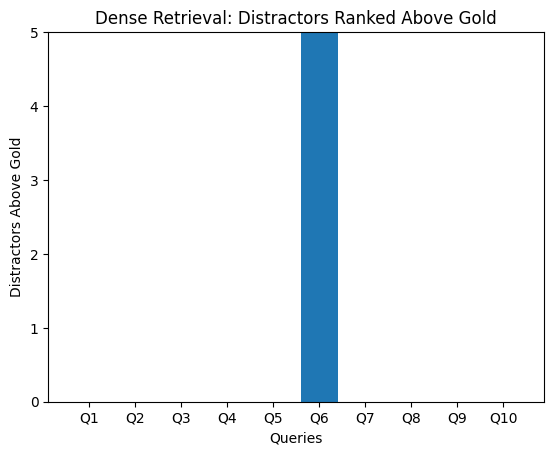

In [21]:
# =========================================
# 9. BASIC DENSE BASELINE VS DEFENSE EXAMPLE
# =========================================

K_DISTRACTOR_ANALYSIS = 5   # For qualitative inspection
K_EVALUATION = 10           # For retrieval metrics

example_query = query_gold_pairs[0][0]
example_gold_idx = query_gold_pairs[0][1]

print("===== DENSE BASELINE RESULTS =====")
baseline_results = retrieve_topk_precomputed(
    example_query, docs_corpus, doc_emb_corpus, K_DISTRACTOR_ANALYSIS
)
for idx, text, score in baseline_results:
    tag = "GOLD" if idx == example_gold_idx else "DISTRACTOR"
    print(f"[{idx}] {tag} score={score:.4f} | {text[:120]}...")

baseline_rank = get_rank_of_doc(baseline_results, example_gold_idx)
baseline_above_gold = count_distractors_above_gold(baseline_results, example_gold_idx)
print(f"\nGold rank in Dense: {baseline_rank}")
print(f"Distractors above gold in top-{K_DISTRACTOR_ANALYSIS}: {baseline_above_gold}")

print("\n===== DEFENDED DENSE RESULTS =====")
defended_results = retrieve_defended_dense(
    example_query,
    docs_corpus,
    doc_emb_corpus,
    bm25_corpus,
    tfidf_matrix_corpus,
    tfidf_vectorizer,
    top_n=20,
    k=K_DISTRACTOR_ANALYSIS
)
for idx, text, score in defended_results:
    tag = "GOLD" if idx == example_gold_idx else "DISTRACTOR"
    print(f"[{idx}] {tag} score={score:.4f} | {text[:120]}...")

defended_rank = get_rank_of_doc(defended_results, example_gold_idx)
defended_above_gold = count_distractors_above_gold(defended_results, example_gold_idx)
print(f"\nGold rank in Defended Dense: {defended_rank}")
print(f"Distractors above gold in top-{K_DISTRACTOR_ANALYSIS}: {defended_above_gold}")
# =========================================
# 10. QUALITATIVE EVALUATION QUERIES
# =========================================

print("Queries loaded:", len(queries))
for i, q in enumerate(queries, start=1):
    print(f"Q{i}: {q}")

# =========================================
# 11. DENSE DISTRACTOR DOMINANCE
# =========================================

dense_distractor_counts = []

for query, gold_idx in query_gold_pairs:
    results = retrieve_topk_precomputed(
        query, docs_corpus, doc_emb_corpus, K_DISTRACTOR_ANALYSIS
    )
    hits = count_distractors_above_gold(results, gold_idx)
    dense_distractor_counts.append(hits)

plt.figure()
plt.bar(range(len(query_gold_pairs)), dense_distractor_counts)
plt.xticks(range(len(query_gold_pairs)), [f"Q{i+1}" for i in range(len(query_gold_pairs))])
plt.ylim(0, K_DISTRACTOR_ANALYSIS)
plt.xlabel("Queries")
plt.ylabel("Distractors Above Gold")
plt.title("Dense Retrieval: Distractors Ranked Above Gold")
plt.show()


In [29]:
# =========================================
# 12. BM25 DISTRACTOR ANALYSIS
# =========================================

print("===== BM25 RESULTS =====")

for query, gold_idx in query_gold_pairs:
    print("\nQuery:", query)

    results = retrieve_bm25(query, docs_corpus, bm25_corpus, k=K_DISTRACTOR_ANALYSIS)
    distractor_hits = count_distractors_above_gold(results, gold_idx)
    gold_rank = get_rank_of_doc(results, gold_idx)

    print(f"  Gold rank: {gold_rank}")
    print(f"  Distractors above gold: {distractor_hits}")

    for idx, text, score in results:
        tag = "GOLD" if idx == gold_idx else "DISTRACTOR"
        print(f"  - [{idx}] {tag} score={score:.4f} | {text[:90]}...")

# =========================================
# 13. TF-IDF DISTRACTOR ANALYSIS
# =========================================

print("===== TF-IDF RESULTS =====")

for query, gold_idx in query_gold_pairs:
    print("\nQuery:", query)

    results = retrieve_tfidf(
        query, docs_corpus, tfidf_matrix_corpus, tfidf_vectorizer, k=K_DISTRACTOR_ANALYSIS
    )
    distractor_hits = count_distractors_above_gold(results, gold_idx)
    gold_rank = get_rank_of_doc(results, gold_idx)

    print(f"  Gold rank: {gold_rank}")
    print(f"  Distractors above gold: {distractor_hits}")

    for idx, text, score in results:
        tag = "GOLD" if idx == gold_idx else "DISTRACTOR"
        print(f"  - [{idx}] {tag} score={score:.4f} | {text[:90]}...")

# =========================================
# 14. HYBRID DISTRACTOR ANALYSIS
# =========================================

print("===== HYBRID RESULTS =====")

for query, gold_idx in query_gold_pairs:
    print("\nQuery:", query)

    results = retrieve_hybrid(
        query, docs_corpus, doc_emb_corpus, bm25_corpus, k=K_DISTRACTOR_ANALYSIS, alpha=0.5
    )
    distractor_hits = count_distractors_above_gold(results, gold_idx)
    gold_rank = get_rank_of_doc(results, gold_idx)

    print(f"  Gold rank: {gold_rank}")
    print(f"  Distractors above gold: {distractor_hits}")

    for idx, text, score in results:
        tag = "GOLD" if idx == gold_idx else "DISTRACTOR"
        print(f"  - [{idx}] {tag} score={score:.4f} | {text[:90]}...")

# =========================================
# 14.5 DEFENDED DENSE DISTRACTOR ANALYSIS
# =========================================

print("===== DEFENDED DENSE RESULTS =====")

for query, gold_idx in query_gold_pairs:
    print("\nQuery:", query)

    results = retrieve_defended_dense(
        query,
        docs_corpus,
        doc_emb_corpus,
        bm25_corpus,
        tfidf_matrix_corpus,
        tfidf_vectorizer,
        top_n=20,
        k=K_DISTRACTOR_ANALYSIS
    )
    distractor_hits = count_distractors_above_gold(results, gold_idx)
    gold_rank = get_rank_of_doc(results, gold_idx)

    print(f"  Gold rank: {gold_rank}")
    print(f"  Distractors above gold: {distractor_hits}")

    for idx, text, score in results:
        tag = "GOLD" if idx == gold_idx else "DISTRACTOR"
        print(f"  - [{idx}] {tag} score={score:.4f} | {text[:90]}...")

===== BM25 RESULTS =====

Query: why are business leaders worried about artificial intelligence
  Gold rank: 1
  Distractors above gold: 0
  - [7] GOLD score=7.6054 | world s business elite are stressed about our robotic future in davos not everyone is exci...
  - [6] DISTRACTOR score=5.1075 | leaders of top robotics and ai companies call for ban on killer robots elon musk and other...
  - [22] DISTRACTOR score=4.6087 | why are digital assistants like siri given female voices at an artificial intelligence con...
  - [12] DISTRACTOR score=3.8771 | why automation will create not destroy jobs if you have been watching political tectonics ...
  - [18] DISTRACTOR score=3.1076 | ai weiwei nationality and borders are barriers to our intelligence and imagination the wor...

Query: can artificial intelligence predict autism in babies
  Gold rank: 1
  Distractors above gold: 0
  - [14] GOLD score=4.2837 | ai predicts autism based on infant brain scans it was extremely accurate...
  - [1] DISTRAC

In [30]:

# =========================================
# 15. GOLD DOCUMENT RANK TESTS
# =========================================

print("\n===== GOLD DOCUMENT RANK TEST: DENSE vs DEFENDED DENSE =====")
for query, gold_idx in query_gold_pairs:
    dense_results = retrieve_topk_precomputed(
        query, docs_corpus, doc_emb_corpus, k=10
    )
    defended_results = retrieve_defended_dense(
        query,
        docs_corpus,
        doc_emb_corpus,
        bm25_corpus,
        tfidf_matrix_corpus,
        tfidf_vectorizer,
        top_n=20,
        k=10
    )

    dense_rank = get_rank_of_doc(dense_results, gold_idx)
    defended_rank = get_rank_of_doc(defended_results, gold_idx)

    print("\nQuery:", query)
    print("Gold document index:", gold_idx)
    print("Rank in Dense:", dense_rank)
    print("Rank in Defended Dense:", defended_rank)

print("\n===== GOLD DOCUMENT RANK TEST: BM25 =====")
for query, gold_idx in query_gold_pairs:
    bm25_results = retrieve_bm25(
        query, docs_corpus, bm25_corpus, k=10
    )
    bm25_rank = get_rank_of_doc(bm25_results, gold_idx)

    print("\nQuery:", query)
    print("Gold document index:", gold_idx)
    print("Rank in BM25:", bm25_rank)

print("\n===== GOLD DOCUMENT RANK TEST: TF-IDF =====")
for query, gold_idx in query_gold_pairs:
    tfidf_results = retrieve_tfidf(
        query, docs_corpus, tfidf_matrix_corpus, tfidf_vectorizer, k=10
    )
    tfidf_rank = get_rank_of_doc(tfidf_results, gold_idx)

    print("\nQuery:", query)
    print("Gold document index:", gold_idx)
    print("Rank in TF-IDF:", tfidf_rank)

print("\n===== GOLD DOCUMENT RANK TEST: HYBRID =====")
for query, gold_idx in query_gold_pairs:
    hybrid_results = retrieve_hybrid(
        query, docs_corpus, doc_emb_corpus, bm25_corpus, k=10, alpha=0.5
    )
    hybrid_rank = get_rank_of_doc(hybrid_results, gold_idx)

    print("\nQuery:", query)
    print("Gold document index:", gold_idx)
    print("Rank in Hybrid:", hybrid_rank)

print("\n===== GOLD DOCUMENT RANK TEST: LOGISTIC RANKER =====")
for query, gold_idx in query_gold_pairs:
    logistic_results = retrieve_logistic_ranker(
        query,
        docs_corpus,
        doc_emb_corpus,
        bm25_corpus,
        tfidf_matrix_corpus,
        tfidf_vectorizer,
        log_ranker,
        top_n=20,
        k=10
    )
    logistic_rank = get_rank_of_doc(logistic_results, gold_idx)

    print("\nQuery:", query)
    print("Gold document index:", gold_idx)
    print("Rank in Logistic Ranker:", logistic_rank)


===== GOLD DOCUMENT RANK TEST: DENSE vs DEFENDED DENSE =====

Query: why are business leaders worried about artificial intelligence
Gold document index: 7
Rank in Dense: 1
Rank in Defended Dense: 1

Query: can artificial intelligence predict autism in babies
Gold document index: 14
Rank in Dense: 1
Rank in Defended Dense: 1

Query: why do siri and other digital assistants use female voices
Gold document index: 22
Rank in Dense: 1
Rank in Defended Dense: 1

Query: what is facebook doing to build an artificial brain
Gold document index: 29
Rank in Dense: 1
Rank in Defended Dense: 1

Query: how is microsoft describing the benefits of artificial intelligence
Gold document index: 5
Rank in Dense: 1
Rank in Defended Dense: 1

Query: how is artificial intelligence expected to change daily life
Gold document index: 1
Rank in Dense: None
Rank in Defended Dense: None

Query: what breakthrough did google make in the game of go using ai
Gold document index: 8
Rank in Dense: 1
Rank in Defended Den

In [33]:
print(retrieve_logistic_ranker)
print(log_ranker)

<function retrieve_logistic_ranker at 0x000001A53925E020>
LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


In [35]:
# =========================================
# 16. RETRIEVAL METRICS: HIT@10, MRR@10, DISTRACTORS ABOVE GOLD
# =========================================

print("\n===== RETRIEVAL METRICS =====")

evaluation_summary = {}

evaluation_summary["Dense"] = evaluate_single_method(
    query_gold_pairs,
    retrieve_fn=lambda q: retrieve_topk_precomputed(
        q, docs_corpus, doc_emb_corpus, K_EVALUATION
    ),
    k=K_EVALUATION
)

evaluation_summary["BM25"] = evaluate_single_method(
    query_gold_pairs,
    retrieve_fn=lambda q: retrieve_bm25(
        q, docs_corpus, bm25_corpus, K_EVALUATION
    ),
    k=K_EVALUATION
)

evaluation_summary["TF-IDF"] = evaluate_single_method(
    query_gold_pairs,
    retrieve_fn=lambda q: retrieve_tfidf(
        q, docs_corpus, tfidf_matrix_corpus, tfidf_vectorizer, K_EVALUATION
    ),
    k=K_EVALUATION
)

evaluation_summary["Hybrid"] = evaluate_single_method(
    query_gold_pairs,
    retrieve_fn=lambda q: retrieve_hybrid(
        q, docs_corpus, doc_emb_corpus, bm25_corpus, K_EVALUATION, alpha=0.5
    ),
    k=K_EVALUATION
)

evaluation_summary["DefendedDense"] = evaluate_single_method(
    query_gold_pairs,
    retrieve_fn=lambda q: retrieve_defended_dense(
        q,
        docs_corpus,
        doc_emb_corpus,
        bm25_corpus,
        tfidf_matrix_corpus,
        tfidf_vectorizer,
        top_n=20,
        k=K_EVALUATION
    ),
    k=K_EVALUATION
)

evaluation_summary["LogisticRanker"] = evaluate_single_method(
    query_gold_pairs,
    retrieve_fn=lambda q: retrieve_logistic_ranker(
        q,
        docs_corpus,
        doc_emb_corpus,
        bm25_corpus,
        tfidf_matrix_corpus,
        tfidf_vectorizer,
        log_ranker,
        top_n=20,
        k=K_EVALUATION
    ),
    k=K_EVALUATION
)

for method_name, metrics in evaluation_summary.items():
    print(f"\n{method_name}")
    print(f"  Hit@10: {metrics['Hit@10']:.4f}")
    print(f"  MRR@10: {metrics['MRR@10']:.4f}")
    print(f"  Avg Distractors Above Gold: {metrics['Avg Distractors Above Gold']:.4f}")


===== RETRIEVAL METRICS =====

Dense
  Hit@10: 0.9000
  MRR@10: 0.9000
  Avg Distractors Above Gold: 1.0000

BM25
  Hit@10: 0.9000
  MRR@10: 0.7667
  Avg Distractors Above Gold: 1.6000

TF-IDF
  Hit@10: 1.0000
  MRR@10: 0.8000
  Avg Distractors Above Gold: 0.8000

Hybrid
  Hit@10: 0.9000
  MRR@10: 0.8333
  Avg Distractors Above Gold: 1.2000

DefendedDense
  Hit@10: 0.9000
  MRR@10: 0.8333
  Avg Distractors Above Gold: 1.2000

LogisticRanker
  Hit@10: 0.9000
  MRR@10: 0.8333
  Avg Distractors Above Gold: 1.2000


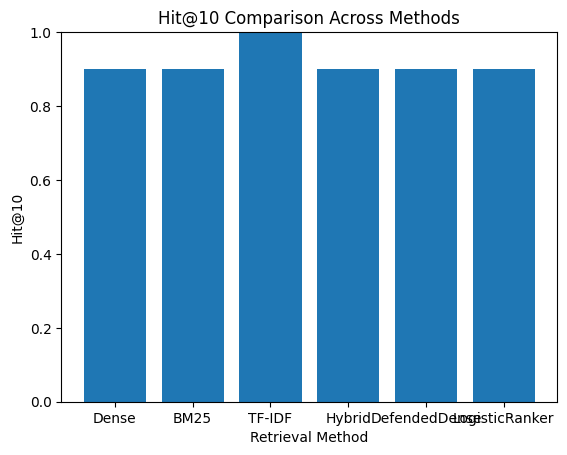

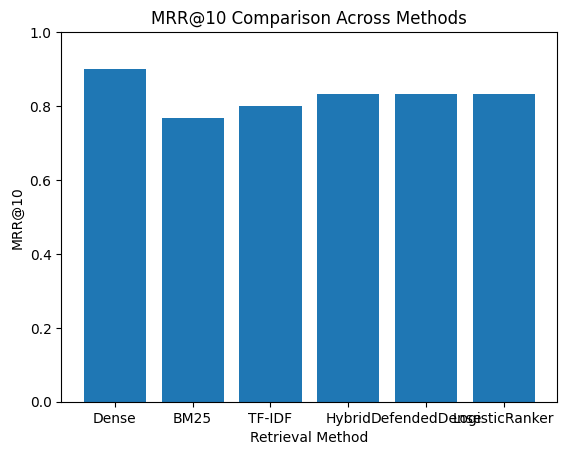

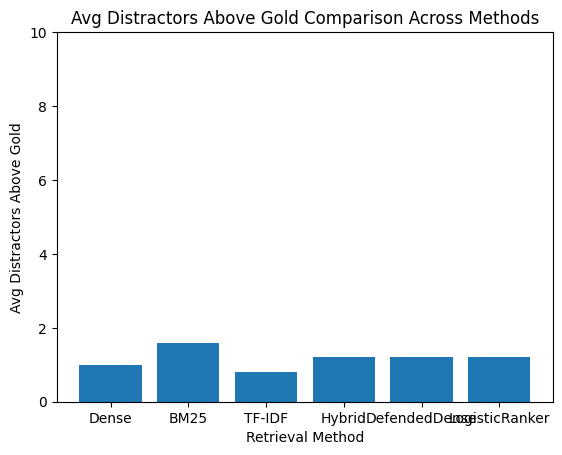

In [36]:
# =========================================
# 17. METRIC VISUALIZATIONS
# =========================================

metric_names = ["Hit@10", "MRR@10", "Avg Distractors Above Gold"]
method_names_metrics = list(evaluation_summary.keys())

for metric in metric_names:
    values = [evaluation_summary[m][metric] for m in method_names_metrics]

    plt.figure()
    plt.bar(method_names_metrics, values)

    if metric in ["Hit@10", "MRR@10"]:
        plt.ylim(0, 1)
    else:
        plt.ylim(0, K_EVALUATION)

    plt.xlabel("Retrieval Method")
    plt.ylabel(metric)
    plt.title(f"{metric} Comparison Across Methods")
    plt.show()

===== METHOD COMPARISON =====

Dense
  why are business leaders worried about artificial intelligence -> Gold rank: 1, Distractors above gold: 0
  can artificial intelligence predict autism in babies -> Gold rank: 1, Distractors above gold: 0
  why do siri and other digital assistants use female voices -> Gold rank: 1, Distractors above gold: 0
  what is facebook doing to build an artificial brain -> Gold rank: 1, Distractors above gold: 0
  how is microsoft describing the benefits of artificial intelligence -> Gold rank: 1, Distractors above gold: 0
  how is artificial intelligence expected to change daily life -> Gold rank: None, Distractors above gold: 5
  what breakthrough did google make in the game of go using ai -> Gold rank: 1, Distractors above gold: 0
  how could ai change love and relationships -> Gold rank: 1, Distractors above gold: 0
  why is artificial intelligence technology said to be breaking out of the box -> Gold rank: 1, Distractors above gold: 0
  what does big da

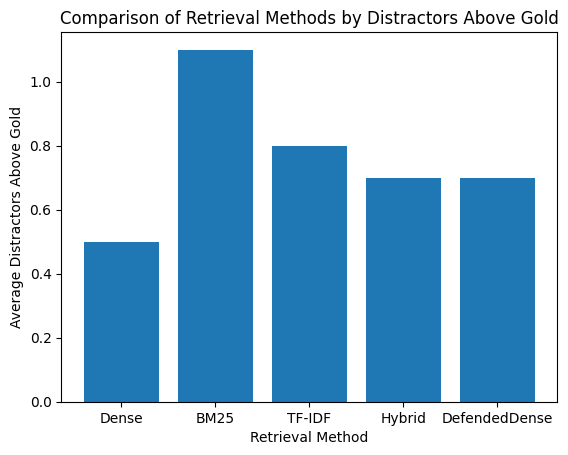

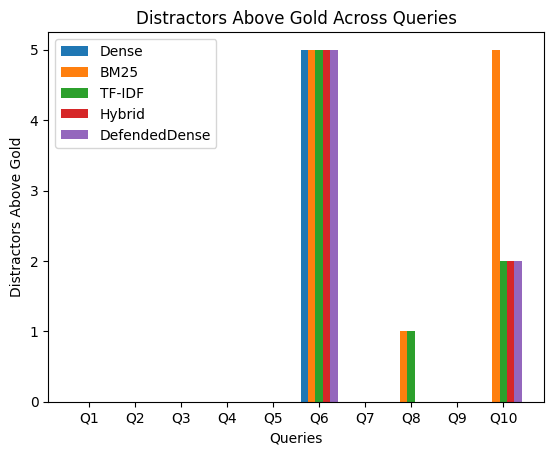

In [37]:
# =========================================
# 18. METHOD COMPARISON USING DISTRACTORS ABOVE GOLD
# =========================================

methods = {
    "Dense": lambda q: retrieve_topk_precomputed(q, docs_corpus, doc_emb_corpus, K_DISTRACTOR_ANALYSIS),
    "BM25": lambda q: retrieve_bm25(q, docs_corpus, bm25_corpus, K_DISTRACTOR_ANALYSIS),
    "TF-IDF": lambda q: retrieve_tfidf(q, docs_corpus, tfidf_matrix_corpus, tfidf_vectorizer, K_DISTRACTOR_ANALYSIS),
    "Hybrid": lambda q: retrieve_hybrid(q, docs_corpus, doc_emb_corpus, bm25_corpus, K_DISTRACTOR_ANALYSIS, alpha=0.5),
    "DefendedDense": lambda q: retrieve_defended_dense(
        q,
        docs_corpus,
        doc_emb_corpus,
        bm25_corpus,
        tfidf_matrix_corpus,
        tfidf_vectorizer,
        top_n=20,
        k=K_DISTRACTOR_ANALYSIS
    ),
}

print("===== METHOD COMPARISON =====")
for method_name, method_fn in methods.items():
    print(f"\n{method_name}")
    for q, gold_idx in query_gold_pairs:
        results = method_fn(q)
        distractor_hits = count_distractors_above_gold(results, gold_idx)
        gold_rank = get_rank_of_doc(results, gold_idx)
        print(f"  {q} -> Gold rank: {gold_rank}, Distractors above gold: {distractor_hits}")

# =========================================
# 19. AUTOMATIC DISTRACTOR-ABOVE-GOLD PLOTS
# =========================================

method_results = {}

for method_name, method_fn in methods.items():
    distractor_list = []
    for q, gold_idx in query_gold_pairs:
        results = method_fn(q)
        distractor_hits = count_distractors_above_gold(results, gold_idx)
        distractor_list.append(distractor_hits)
    method_results[method_name] = distractor_list

print("Computed distractors-above-gold automatically:")
for method_name, distractor_list in method_results.items():
    print(method_name, "->", distractor_list)

# Average distractors above gold per method
method_names = list(method_results.keys())
avg_scores = [np.mean(method_results[m]) for m in method_names]

plt.figure()
plt.bar(method_names, avg_scores)
plt.xlabel("Retrieval Method")
plt.ylabel("Average Distractors Above Gold")
plt.title("Comparison of Retrieval Methods by Distractors Above Gold")
plt.show()

# Distractors above gold per query for each method
queries_labels = [f"Q{i+1}" for i in range(len(query_gold_pairs))]
x = np.arange(len(queries_labels))
width = 0.16

plt.figure()
for i, method_name in enumerate(method_names):
    plt.bar(
        x + (i - (len(method_names)-1)/2) * width,
        method_results[method_name],
        width,
        label=method_name
    )

plt.xticks(x, queries_labels)
plt.xlabel("Queries")
plt.ylabel("Distractors Above Gold")
plt.title("Distractors Above Gold Across Queries")
plt.legend()
plt.show()

In [39]:
# =========================================
# 20. FINAL SUMMARY
# =========================================

print("\n===== FINAL SUMMARY =====")
print("This notebook evaluates retrieval robustness using real distractor documents from the dataset.")
print("We compared Dense, BM25, TF-IDF, Hybrid, and Defended Dense retrieval.")
print("We measured:")
print("1. Gold document rank across retrieval methods")
print("2. Hit@10 and MRR@10 for each method")
print("3. Average number of distractors ranked above the gold document")
print("These results show how retrieval methods behave when semantically similar but non-gold real documents compete with the correct result.")
print("The defended reranking method combines semantic and lexical signals to reduce distractors above the gold document and improve retrieval robustness.")


===== FINAL SUMMARY =====
This notebook evaluates retrieval robustness using real distractor documents from the dataset.
We compared Dense, BM25, TF-IDF, Hybrid, and Defended Dense retrieval.
We measured:
1. Gold document rank across retrieval methods
2. Hit@10 and MRR@10 for each method
3. Average number of distractors ranked above the gold document
These results show how retrieval methods behave when semantically similar but non-gold real documents compete with the correct result.
The defended reranking method combines semantic and lexical signals to reduce distractors above the gold document and improve retrieval robustness.
